# MSM analysis

In [119]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from deeptime.plots import Network
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

from matplotlib.patches import Patch
from matplotlib import color_sequences
macro_color_sequence = color_sequences['Paired']

n_macro = 6
timelag_macro = 1000 # validated with the CK test, see notebook step_3_msm_construction.ipynb

---
# Thermodynamics questions

- equilibrium populations and free energy landscape
- structural caracterization of metastable states: fraction of native contacts, RMSD to crystal, radius of gyration
- representative conformations: visualization with PyMol

In [124]:
macro_traj = np.load(f"intermediate_outputs/traj_pcca_{n_macro}_assignments.npy")
pca_traj = np.load("intermediate_outputs/mindists2_pca_5.npz")['arr_0']


Q_timeseries = np.load("intermediate_outputs/Q_timeseries.npy")
RMSD_timeseries = np.load("intermediate_outputs/RMSD_crystal_nm.npy")


MoSAIC_dict = {
    1 : [(3,14), (3, 13), (6,14), (5, 14)],
    2: [(7, 12), (7, 13), (6,12), (7,11), (6, 11), (6, 17)],
    3: [(12,17), (12,16), (12,20), (13, 17)],
    4: [(18,25), (17,25), (20, 25)],
    5: [(24, 28), (20, 28), (25, 29)],
    6: [(29,35), (29,34), (30,35), (29,33)],
    7: [(10,34), (9,32), (10,29)]
}


def cluster_idx(contact_tuple):
    idx = None
    for i in MoSAIC_dict.keys():
        if contact_tuple in MoSAIC_dict[i]:
            idx = i
            continue
    if idx == None:
        idx = 8
    return idx


contacts = [tuple(x) for x in np.loadtxt(
            "data/hp35.mindists2.ndx",
            comments="#",
            usecols=(0, 1),
            dtype=int
        )
    ]

# reconstruct cluster 8:
contacts_cluster_8 = [contact for contact in contacts if cluster_idx(contact) == 8]
MoSAIC_dict[8] = contacts_cluster_8

contacts_each_cluster = {id: len(contacts) for id, contacts in MoSAIC_dict.items()}


subsets = ['MoSAIC1', 'MoSAIC2', 'MoSAIC3', 'MoSAIC4', 'MoSAIC5', 'MoSAIC6', 'MoSAIC7', 'MoSAIC8']
filenames = [f"intermediate_outputs/totdist_timeseries_{subset}.npy" for subset in subsets]

MoSAIC_totdist_timeseries = [np.load(filename) for filename in filenames]
MoSAIC_totdist_timeseries = [MoSAIC_totdist_timeseries[i] / contacts_each_cluster[i+1] for i in range(len(MoSAIC_totdist_timeseries))]
MoSAIC_totdist_timeseries = np.array(MoSAIC_totdist_timeseries)

# MoSAIC colors
## DO NOT CHANGE THESE COLORS
# they are the same as used in the pymol script


MoSAIC_colors = [
[1.00, 0.15, 0.15],
[0.10, 0.35, 1.00],
[0.10, 0.75, 0.20],
[1.00, 0.55, 0.00],
[0.65, 0.20, 0.90],
[0.00, 0.75, 0.75],
[0.95, 0.85, 0.10],
"grey"
]

Re-index macrostates by increasing fraction of native contacts

In [125]:
median_Q_per_macrostate = []
for id in range(n_macro):
    frames = Q_timeseries[macro_traj == id]
    median_Q_per_macrostate.append(np.median(frames))

# Renumber macrostates by median Q
sorted_indices = np.argsort(median_Q_per_macrostate)

dict = {old: new for new, old in enumerate(sorted_indices)}
macro_traj = np.array([dict[old] for old in macro_traj])

#### Compute statistics per macrostate (1- Q, RMSD) 

In [126]:
def make_violin_plot(ax, macro_traj, observable_traj, n_macro):


    # Collect observable values for each macrostate
    data = [
        observable_traj[macro_traj == i]
        for i in range(n_macro)
    ]
    populations = np.bincount(macro_traj) / len(macro_traj)

    vp = ax.violinplot(
        data,
        positions=np.arange(n_macro),
        widths=0.2 + populations / populations.max(),
        showmeans=True,
        showmedians=True,
        showextrema=False,
    )

    # Color violins
    for body, color in zip(vp['bodies'], macro_color_sequence[:n_macro]):
        body.set_facecolor(color)
        body.set_edgecolor('black')
        body.set_alpha(0.7)

    # Style mean/median lines
    vp['cmeans'].set_color('black')
    vp['cmedians'].set_color('white')
    vp['cmedians'].set_linewidth(2)

    ax.set_xticks(np.arange(n_macro))
    ax.set_xticklabels([f"S{i}" for i in range(n_macro)])
    ax.set_xlabel("Macrostate")
    

    return ax, vp

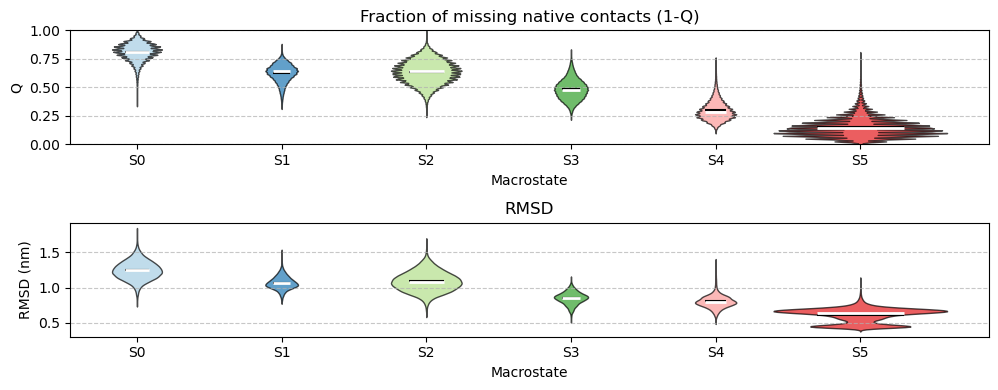

In [127]:
fig, axs = plt.subplots(nrows = 2, ncols = 1, figsize=(10, 4))


ax = axs[0]
ax, vp = make_violin_plot(ax, macro_traj, 1- Q_timeseries, n_macro)
ax.set_title("Fraction of missing native contacts (1-Q)")
ax.set_ylim(0, 1)
ax.set_ylabel("Q")
ax.grid(axis='y', linestyle='--', alpha=0.7)


ax = axs[1]
ax, vp = make_violin_plot(ax, macro_traj, RMSD_timeseries, n_macro)
ax.set_title("RMSD")
ax.set_ylabel("RMSD (nm)")
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

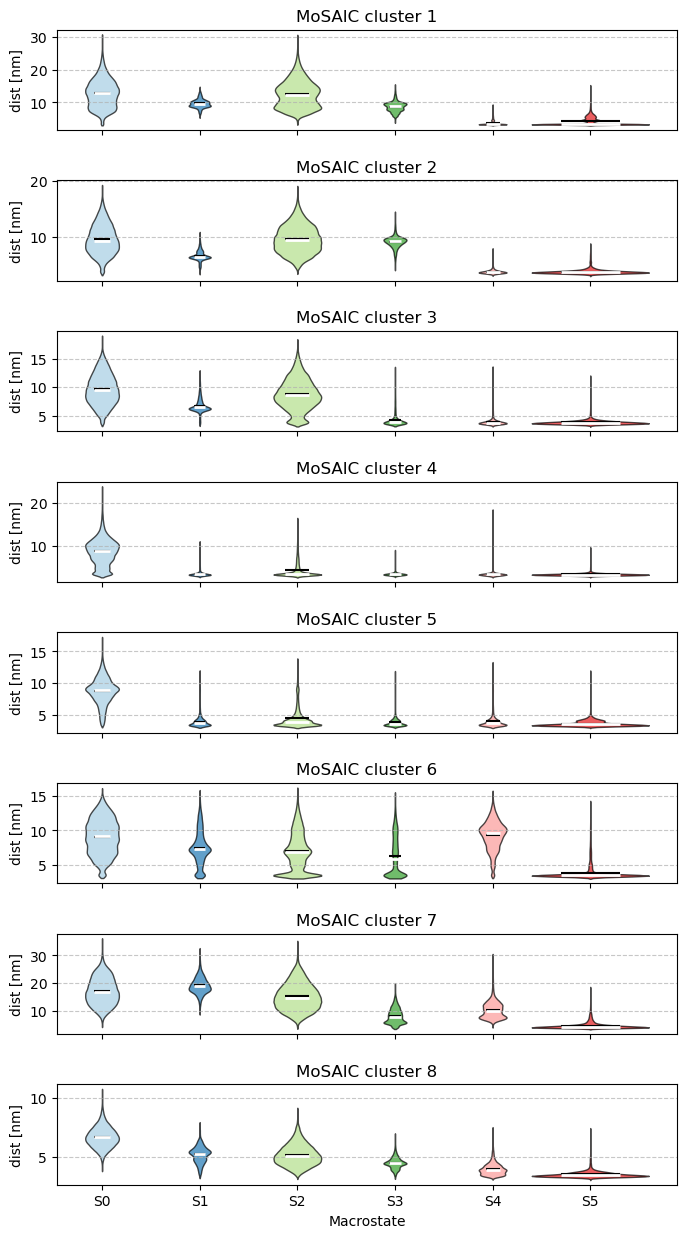

In [129]:
fig, axs = plt.subplots(nrows=len(MoSAIC_colors), ncols=1, figsize=( len(MoSAIC_colors), 15))
for i, series in enumerate(MoSAIC_totdist_timeseries):
    ax = axs[i]
    ax, vp = make_violin_plot(ax, macro_traj, series, n_macro)
    ax.set_title(f"MoSAIC cluster {i+1}")
    ax.set_ylabel("dist [nm]")
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if i < len(MoSAIC_totdist_timeseries) - 1:
        ax.set_xticklabels([]) 
        ax.set_xlabel("")

plt.subplots_adjust(hspace=0.5)
plt.show()

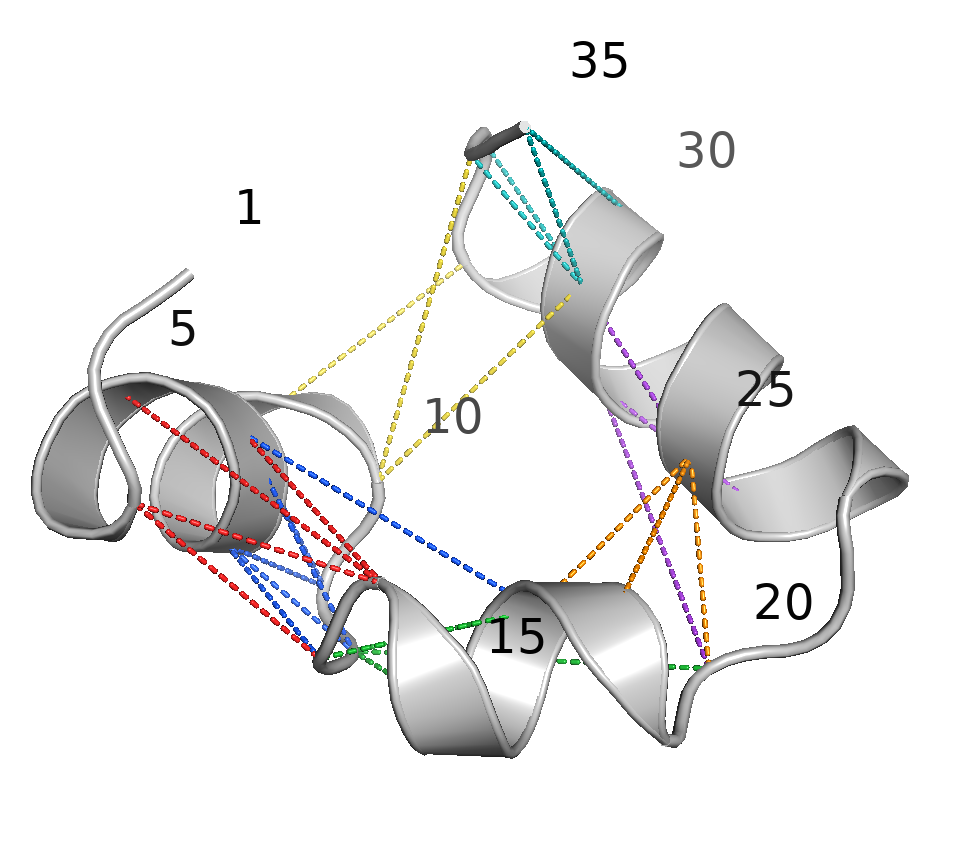

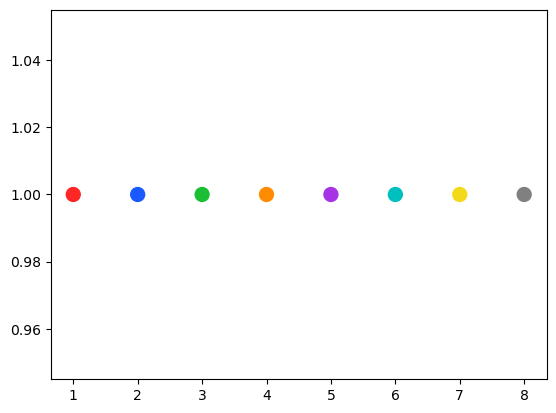

In [140]:
from IPython import display
plt.scatter(range(1, len(MoSAIC_colors)+ 1), np.ones(len(MoSAIC_colors)), s = 100, color = MoSAIC_colors)
display.Image("pymol/contacts1.png", width = 300)

**Comments**

- The two states that are most folded, i.e. S5 and S4, mostly appear to differ by the orientation of the C terminus (MoSAIC clusters 6 and 7)
- MoSAIC cluster 8, which consists mostly of helix-stabilizing contacts, appears to correlate very well to the scalar folding coordinate 1-Q. Indeed, the macrostates, that where ordered by increasing median Q, keep the same ordering as far as only Q of cluster 8 is considered.

---
# Dynamics questions

- mean first passage times, in particular: unfolded->folded predicted timescale
- forward committor
- reactive fluxes and dominant pathways

In [108]:
estimator_counts = TransitionCountEstimator(
    lagtime=int(timelag_macro),
    count_mode="sliding-effective"
)
macro_counts = estimator_counts.fit(macro_traj).fetch_model()

print("Weakly connected sets:", macro_counts.connected_sets(directed=False))
print("Strongly connected sets:", macro_counts.connected_sets(directed=True))


estimator_transition = MaximumLikelihoodMSM(
    reversible=True,
    stationary_distribution_constraint=None
)
macro_msm = estimator_transition.fit(macro_counts).fetch_model()

Weakly connected sets: [array([0, 1, 2, 3, 4, 5])]
Strongly connected sets: [array([0, 1, 2, 3, 4, 5])]


In [109]:
print("Self-transition probabilities:", macro_msm.transition_matrix.diagonal())

Self-transition probabilities: [0.53020692 0.48125402 0.61733039 0.23280895 0.11471912 0.89594444]


In [110]:
def plot_msm_network(
    T,
    ax=None,
    state_colors=None,
    pi=None,
    labels=None,
    top_k_per_state=2,
    min_prob=0.02,
    node_size_range=(800, 3500),
    edge_width_range=(1.0, 6.0),
    self_edges=False,
    seed=0,
):
    T = np.asarray(T, dtype=float)
    n = T.shape[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    if labels is None:
        labels = {i: str(i) for i in range(n)}
    else:
        labels = {i: str(labels[i]) for i in range(n)}

    if state_colors is None:
        state_colors = ["lightgrey"] * n

    if pi is None:
        # left stationary distribution for row-stochastic T
        w, v = np.linalg.eig(T.T)
        idx = np.argmin(np.abs(w - 1))
        pi = np.real(v[:, idx])
        pi = np.abs(pi)
        pi = pi / pi.sum()

    # -----------------------------
    # Full graph for layout
    # -----------------------------
    G_full = nx.from_numpy_array(T, create_using=nx.DiGraph())

    pos = nx.spring_layout(
        G_full,
        weight="weight",
        k=5,
        seed=seed
    )

    # -----------------------------
    # Filter edges for plotting
    # -----------------------------
    G_plot = nx.DiGraph()
    G_plot.add_nodes_from(range(n))

    for i in range(n):
        probs = T[i].copy()

        if not self_edges:
            probs[i] = 0.0

        candidates = np.where(probs >= min_prob)[0]

        if len(candidates) > 0:
            strongest = candidates[np.argsort(probs[candidates])[-top_k_per_state:]]

            for j in strongest:
                G_plot.add_edge(i, j, weight=T[i, j])

    # -----------------------------
    # Node sizes
    # -----------------------------
    smin, smax = node_size_range
    if np.max(pi) > np.min(pi):
        node_sizes = smin + (pi - pi.min()) / (pi.max() - pi.min()) * (smax - smin)
    else:
        node_sizes = np.full(n, 0.5 * (smin + smax))

    # -----------------------------
    # Edge widths
    # -----------------------------
    edges = list(G_plot.edges())
    weights = np.array([G_plot[u][v]["weight"] for u, v in edges])

    if len(weights) > 0 and weights.max() > weights.min():
        wmin, wmax = edge_width_range
        edge_widths = wmin + (weights - weights.min()) / (weights.max() - weights.min()) * (wmax - wmin)
    elif len(weights) > 0:
        edge_widths = np.full(len(weights), np.mean(edge_width_range))
    else:
        edge_widths = []

    # -----------------------------
    # Draw
    # -----------------------------
    nx.draw_networkx_nodes(
        G_plot,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=state_colors,
        edgecolors="black",
        linewidths=1.5,
        alpha = 0.6
    )

    nx.draw_networkx_labels(
        G_plot,
        pos,
        labels=labels,
        ax=ax,
        font_size=11,
        font_weight="bold"
    )

    nx.draw_networkx_edges(
        G_plot,
        pos,
        ax=ax,
        edgelist=edges,
        width=edge_widths,
        arrows=True,
        arrowsize=15,
        arrowstyle="-|>",
        min_target_margin=25,
        min_source_margin=20,
        connectionstyle="arc3,rad=0.15",
        alpha=0.75
    )

    ax.set_title("Dominant macrostate transitions")
    ax.axis("off")

    return ax, G_plot, pos

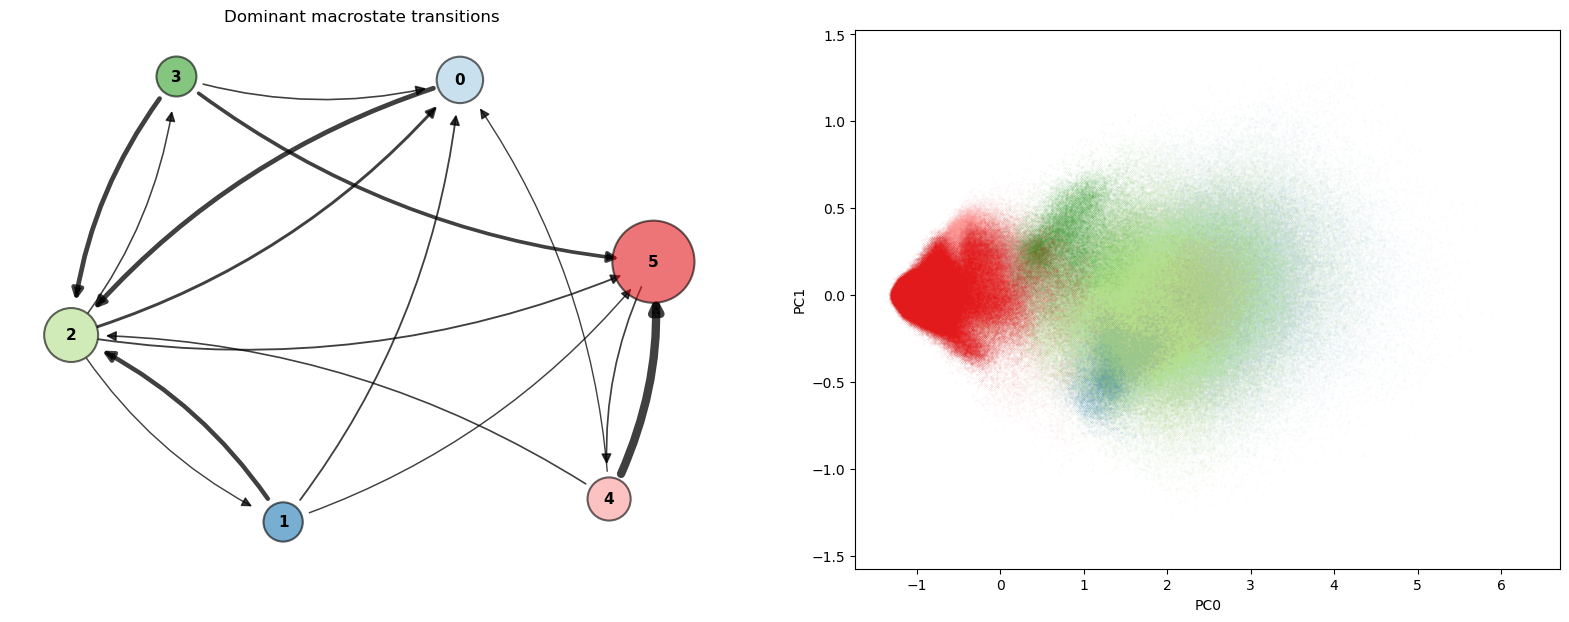

In [111]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 7))

#############################
# graph transition matrix

ax = axs[0]
ax, G_plot, pos = plot_msm_network(
    macro_msm.transition_matrix,
    ax=ax,
    state_colors=macro_color_sequence[:n_macro],
    top_k_per_state=4,
    min_prob=0.03,
    self_edges=False,
    seed=0
)

#############################
# pca plot
ax = axs[1]
for id in range(n_macro):
    frames = pca_traj[macro_traj == id]
    ax.scatter(
        frames[:, 0],
        frames[:, 4],
        color=macro_color_sequence[id],
        alpha = 0.3,
        s=0.01,
    )
ax.set_xlabel(f"PC0")
ax.set_ylabel(f"PC1")

plt.show()